In [19]:
import pandas as pd
import pandas_datareader.data as web
from datetime import datetime
import geopandas as gpd
import numpy as np
import os
import pathlib
import glob
import re
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

In [20]:
HOME_DIR = pathlib.Path.home()
M_DRIVE = pathlib.Path('/Volumes/Data/Models') if os.name=='posix' else pathlib.Path('M:/')

box_path = HOME_DIR / 'Library/CloudStorage/Box-Box'
data_base_path = M_DRIVE / 'Data/Census/PUMS'

print(f"Baseline Data Path: {data_base_path}")

Baseline Data Path: M:\Data\Census\PUMS


## Crosswalks

In [21]:
# 2010s era pumas
puma_x_county_2010_path = M_DRIVE / 'Crosswalks/geo/block-to-puma/stpuma_to_county_2019.csv'
# 2020s era pumas
puma_x_county_2020_path = M_DRIVE / 'Crosswalks/geo/block-to-puma/stpuma_to_county_2024.csv'
puma_x_county_2010 = pd.read_csv(puma_x_county_2010_path,dtype=str)
puma_x_county_2020 = pd.read_csv(puma_x_county_2020_path,dtype=str)
puma_x_county_2010 = puma_x_county_2010.set_index('STPUMA').counties
puma_x_county_2020 = puma_x_county_2020.set_index('STPUMA').counties

# Table Disambiguation and Load Configurations
To accurately load both Person and Household files without column name overlap or weight truncation, we maintain separate `keep_cols` lists and write a unified, robust multi-table loader.

In [104]:
# Canonical columns to keep per table. Each canonical name resolves to itself
# unless an entry in COLUMN_ALIASES lists alternate source headers.
REPLICATE_WEIGHTS = range(1, 81)

PERSON_COLS = ["SERIALNO", "ST", "PUMA", "AGEP", "PWGTP"] + [f"PWGTP{i}" for i in REPLICATE_WEIGHTS]
# VACS = vacancy status: populated only for VACANT units (occupied units are blank/NA),
# so it doubles as a vacant-unit flag. Vacant records survive in h_df but are dropped by
# the inner person merge, which is why the vacancy analysis runs off h_df.
HOUSEHOLD_COLS = ["SERIALNO", "ST", "PUMA", "NP", "BLD", "YRBLT", "HINCP", "VACS", "WGTP"] + [f"WGTP{i}" for i in REPLICATE_WEIGHTS]

# Keyed by the CANONICAL keep-col name -> ordered list of acceptable source headers
# (the source files call state "STATE", so "ST" must alias to it or it gets dropped).
COLUMN_ALIASES = {
    "ST":    ["ST", "STATE"],
    "PUMA":  ["PUMA", "PUMA10", "PUMA00"],
    "AGEP":  ["AGEP", "AGE"],
    "HINCP": ["HINCP", "HHINCP"],
    # Year structure built: 2020+ vintages call it YRBLT (4-digit start-year, decade
    # bins for older); 2017 & earlier call it YBL (2-digit code, finer single-year bins
    # post-2004). Harmonized to a common decade downstream.
    "YRBLT": ["YRBLT", "YBL"],
}

ID_STR_COLS = {"SERIALNO", "ST", "PUMA"}

# Identifier columns are read as strings so leading zeros (state FIPS, PUMA) survive.

In [44]:
def resolve_columns(available, keep_cols):
    """Map each canonical keep-col to its actual header name in this file."""
    available_upper = {col.upper(): col for col in available}
    col_map = {}
    for canon in keep_cols:
        for alias in COLUMN_ALIASES.get(canon, [canon]):
            src = available_upper.get(alias.upper())
            if src is not None:
                col_map[canon] = src
                break
    return col_map

def load_pums_file_type(base_path, year, keep_cols, table_type='person', state_fips='06'):
    """Load a targeted PUMS table (person or household) for one vintage across its segment files.

    state_fips : 2-digit FIPS string selects a state-specific file (e.g. '06' -> p06/h06
                 for California). Pass None (or 'us') to load the national pus/hus files.
    """
    prefix = 'p' if table_type.lower() == 'person' else 'h'
    if state_fips in (None, 'us', 'US'):
        tag = f'{prefix}us'            # national file, e.g. psam_pusa.csv
    else:
        tag = f'{prefix}{state_fips}'  # state file, e.g. psam_p06.csv (CA)
    yy = str(year)[-2:]
    year_path = pathlib.Path(base_path) / f"PUMS {year}"

    patterns = (f"psam_{tag}*.csv", f"ss{yy}{tag}*.csv")
    files = []
    for pat in patterns:
        files.extend(sorted(year_path.glob(pat)))
    if not files:
        attempted = "\n".join(str(year_path / pat) for pat in patterns)
        raise FileNotFoundError(
            f"No {table_type} files found for {year}. Tried:\n{attempted}"
        )

    dfs = []
    for f in files:
        header = pd.read_csv(f, nrows=0).columns.tolist()
        col_map = resolve_columns(header, keep_cols)

        # Surface silently-dropped columns (ignore the replicate-weight families).
        missing = [c for c in keep_cols
                   if c not in col_map and not c.startswith(('PWGTP', 'WGTP'))]
        if missing:
            print(f"  ! {f.name}: could not resolve {missing}")
        if not col_map:
            continue

        str_dtypes = {src: str for canon, src in col_map.items() if canon in ID_STR_COLS}
        df = pd.read_csv(f, usecols=list(col_map.values()), dtype=str_dtypes)
        df = df.rename(columns={src: canon for canon, src in col_map.items()})
        df["year"] = year
        dfs.append(df)

    return pd.concat(dfs, ignore_index=True) if dfs else pd.DataFrame()

In [105]:
# Load target vintage and execute separate extraction processes
TARGET_YEARS = [2017,2024]  # Adjust as needed
STATE_FIPS = '06'           # '06' = California state file (p06/h06); set to None for the national pus/hus file

print("--- Loading Persons Table ---")
p_df = pd.concat([load_pums_file_type(data_base_path, y, PERSON_COLS, 'person', STATE_FIPS) for y in TARGET_YEARS], ignore_index=True)

print("--- Loading Households Table ---")
h_df = pd.concat([load_pums_file_type(data_base_path, y, HOUSEHOLD_COLS, 'household', STATE_FIPS) for y in TARGET_YEARS], ignore_index=True)

print(f"Persons Raw Shape: {p_df.shape} | Households Raw Shape: {h_df.shape}")

--- Loading Persons Table ---
--- Loading Households Table ---
Persons Raw Shape: (771300, 86) | Households Raw Shape: (325867, 90)


In [47]:
h_df.sample(10)

,SERIALNO,PUMA,ST,WGTP,NP,BLD,YRBLT,HINCP,WGTP1,WGTP2,...,WGTP72,WGTP73,WGTP74,WGTP75,WGTP76,WGTP77,WGTP78,WGTP79,WGTP80,year
207738,2024HU0302271,08508,06,120,2,2.0,1960.0,190000.0,33,116,...,37,121,189,32,36,214,135,117,37,2024
217333,2024HU0396648,06707,06,72,1,3.0,1970.0,105000.0,89,22,...,147,127,120,71,19,77,149,75,110,2024
2284,2017000022253,03735,06,43,3,5.0,5.0,70000.0,35,12,...,40,46,45,49,69,11,36,40,74,2017
319040,2024HU1396939,05301,06,199,2,9.0,2000.0,3000.0,58,313,...,64,183,249,237,185,247,370,196,327,2024
68340,2017000668212,03715,06,61,4,2.0,2.0,45400.0,105,64,...,103,65,17,67,18,95,61,16,20,2017
270007,2024HU0914406,01700,06,220,0,2.0,1970.0,NaN,218,253,...,79,372,242,244,70,206,66,68,245,2024
10948,2017000106513,09702,06,170,0,7.0,7.0,NaN,180,183,...,166,166,53,163,318,288,267,145,46,2017
43479,2017000424844,03748,06,103,1,8.0,6.0,69300.0,25,181,...,165,96,27,31,29,102,189,32,166,2017
295428,2024HU1163933,01902,06,196,5,2.0,1990.0,169200.0,208,49,...,284,191,70,314,215,367,179,57,347,2024
294548,2024HU1155223,01313,06,74,3,2.0,2010.0,678000.0,109,146,...,65,107,132,22,20,136,82,24,70,2024


In [48]:
# === Weighted statistics helpers (survey weights → unbiased medians/quantiles) ===
def weighted_quantiles(values, weights, quantiles):
    """NaN-aware weighted quantiles. Returns {q: value} using linear interpolation."""
    mask = values.notna()
    v = np.asarray(values[mask], dtype=float)
    w = np.asarray(weights[mask], dtype=float)
    if v.size == 0:
        return {q: np.nan for q in quantiles}
    order = np.argsort(v)
    v, w = v[order], w[order]
    # Cumulative weight at the midpoint of each observation, normalized to [0, 1]
    cum = (np.cumsum(w) - 0.5 * w) / w.sum()
    return {q: float(np.interp(q, cum, v)) for q in quantiles}


def weighted_median(values, weights):
    return weighted_quantiles(values, weights, [0.5])[0.5]


def weighted_mean(values, weights):
    mask = values.notna()
    return np.average(values[mask], weights=weights[mask]) if mask.any() else np.nan


# Household-level Preparation (before the merge)
Geography, inflation adjustment, and income segmentation are computed on the **household** table first. Income quartiles are therefore weighted by households (`WGTP`) and not biased by the person-level explosion that happens at the merge. We attach counties from the PUMA crosswalk and optionally subset to a region (Bay Area by default).

In [106]:
# === Household-level feature engineering (operates on h_df BEFORE the merge) ===

# 1. Inflation-adjust household income (HINCP) to the latest target year via FRED CPI.
try:
    cpi_factors = web.DataReader("CPIAUCSL", "fred", start=datetime(2015, 1, 1))
    annual_cpi = cpi_factors.resample("YE").mean().rename(lambda ts: ts.year).to_dict()['CPIAUCSL']
    base_cpi = annual_cpi[max(TARGET_YEARS)]
    factors = {yr: base_cpi / cpi for yr, cpi in annual_cpi.items()}
except Exception:
    print("FRED CPI pull unavailable; defaulting adjustment factors to 1.0.")
    factors = {yr: 1.0 for yr in TARGET_YEARS}

h_df['HINCP_adj'] = h_df['HINCP'] * h_df['year'].map(factors)

# 1b. Harmonize year-structure-built across vintages into a common decade.
#     2017 YBL is a 2-digit code; 2024 YRBLT is a 4-digit start-year. Both are mapped
#     to the START YEAR of their interval, then binned to a decade common to both.
YBL_START_YEAR = {  # 2017-era YBL code -> start year of the interval it represents
    '01': 1939, '02': 1940, '03': 1950, '04': 1960, '05': 1970, '06': 1980,
    '07': 1990, '08': 2000, '09': 2005, '10': 2006, '11': 2007, '12': 2008,
    '13': 2009, '14': 2010, '15': 2011, '16': 2012, '17': 2013, '18': 2014,
    '19': 2015, '20': 2016, '21': 2017,
}

def _yearbuilt_start(v):
    """Return the interval start-year for either a YBL code or a YRBLT year.

    YBL (2017 & earlier) is a code in 1..21 (read as int, so '01' -> 1); YRBLT (2020+)
    is a 4-digit start-year (>= 1939). The two ranges are disjoint, so magnitude
    alone disambiguates them.
    """
    if pd.isna(v):
        return np.nan
    n = int(float(v))
    if n <= 21:                          # YBL 2-digit code space
        return YBL_START_YEAR[f'{n:02d}']
    return n                             # YRBLT 4-digit start-year

_decade_edges = [-np.inf, 1940, 1950, 1960, 1970, 1980, 1990, 2000, 2010, 2020, np.inf]
_decade_labels = ['Pre-1940', '1940s', '1950s', '1960s', '1970s', '1980s',
                  '1990s', '2000s', '2010s', '2020+']
h_df['yrblt_start'] = h_df['YRBLT'].map(_yearbuilt_start)
h_df['yrblt_decade'] = pd.cut(h_df['yrblt_start'], bins=_decade_edges,
                              labels=_decade_labels, right=False)

# 2. Attach counties from the STPUMA crosswalk (state FIPS + PUMA -> county name).
#    PUMA boundaries changed with the 2020 Census: ACS 2012-2021 use 2010-vintage PUMAs,
#    ACS 2022+ use 2020-vintage PUMAs. Pick the crosswalk per row's survey year so 2017
#    (2010 PUMAs) and 2024 (2020 PUMAs) both resolve to the correct county.
PUMA_VINTAGE_BOUNDARY = 2022   # first ACS year defined on 2020-Census PUMAs
PUMA_CROSSWALKS = {'2010': puma_x_county_2010, '2020': puma_x_county_2020}

h_df['STPUMA'] = h_df['ST'] + h_df['PUMA']
h_df['puma_vintage'] = np.where(h_df['year'] >= PUMA_VINTAGE_BOUNDARY, '2020', '2010')
h_df['county'] = pd.Series(pd.NA, index=h_df.index, dtype='object')
for _vintage, _xwalk in PUMA_CROSSWALKS.items():
    _mask = h_df['puma_vintage'] == _vintage
    h_df.loc[_mask, 'county'] = h_df.loc[_mask, 'STPUMA'].map(_xwalk)

# 3. Optional geographic subset — set COUNTY_SUBSET = None to keep the full national sample.
BAY_AREA_COUNTIES = [
    'Alameda County', 'Contra Costa County', 'Marin County', 'Napa County',
    'San Francisco County', 'San Mateo County', 'Santa Clara County',
    'Solano County', 'Sonoma County',
]
COUNTY_SUBSET = BAY_AREA_COUNTIES   # <-- change to None (or another county list) to widen the sample

if COUNTY_SUBSET is not None:
    h_df = h_df[h_df['county'].isin(COUNTY_SUBSET)].copy()

# 4. Income segmentation — weighted quartiles on HOUSEHOLDS (WGTP), computed on the
#    current (possibly subset) geography so the cutpoints reflect the study area.
qcuts = weighted_quantiles(h_df['HINCP_adj'], h_df['WGTP'], [0.25, 0.50, 0.75])
median_income = qcuts[0.50]

h_df['income_group'] = pd.Categorical(
    np.where(h_df['HINCP_adj'] >= median_income, 'Above median', 'Below median'),
    categories=['Below median', 'Above median'], ordered=True,
)
h_df['income_quartile'] = pd.cut(
    h_df['HINCP_adj'],
    bins=[-np.inf, qcuts[0.25], qcuts[0.50], qcuts[0.75], np.inf],
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)'],
)

geo_label = 'national' if COUNTY_SUBSET is None else f'{len(COUNTY_SUBSET)} counties'
print(f"Households after geo subset ({geo_label}): {h_df.shape[0]:,}")
print(f"Weighted household income — median: ${median_income:,.0f}")
print("Quartile cutpoints: " + ", ".join(f"{int(q*100)}th=${v:,.0f}" for q, v in qcuts.items()))


Households after geo subset (9 counties): 66,652
Weighted household income — median: $130,323
Quartile cutpoints: 25th=$63,000, 50th=$130,323, 75th=$239,317


In [107]:
# === Merge persons onto their household attributes, then add person-level features ===

# Drop the person table's geography (identical to the household's) to avoid _x/_y collisions.
# Inner join also restricts persons to the household geo subset selected above.
merged_df = pd.merge(
    p_df.drop(columns=['ST', 'PUMA'], errors='ignore'),
    h_df, on=['SERIALNO', 'year'], how='inner',
)

# Recode building type (BLD) -> multifamily flag. PUMS codes 04-09 are multi-unit structures.
bld_mapping = {
    '01': 'Mobile home/trailer',
    '02': 'One-family house detached',
    '03': 'One-family house attached',
    '04': '2 Apartments',
    '05': '3-4 Apartments',
    '06': '5-9 Apartments',
    '07': '10-19 Apartments',
    '08': '20-49 Apartments',
    '09': '50 or more apartments',
    '10': 'Boat, RV, van, etc.',
}
MULTIFAMILY_CODES = ['04', '05', '06', '07', '08', '09']

merged_df['bld_code'] = merged_df['BLD'].fillna(-1).map(lambda x: f'{x:02.0f}')
merged_df['bld_desc'] = merged_df['bld_code'].map(bld_mapping)
merged_df['is_multifamily'] = merged_df['bld_code'].isin(MULTIFAMILY_CODES)
# Person-weight credited only to multifamily residents — lets pivot_table sum the
# numerator and denominator separately so margin totals stay correctly weighted.
merged_df['mf_weight'] = merged_df['PWGTP'].where(merged_df['is_multifamily'], 0)

# San Francisco vs. rest-of-region split (a geographic segment for the plots below).
merged_df['is_sanfrancisco'] = pd.Categorical(
    np.where(merged_df['county'] == 'San Francisco County', 'San Francisco', 'Rest of region'),
    categories=['Rest of region', 'San Francisco'], ordered=True,
)

# Person-level age bracketing
age_bins = [0, 18, 30, 45, 65, 120]
age_labels = ['<18', '18-29', '30-44', '45-64', '65+']
merged_df['age_group'] = pd.cut(merged_df['AGEP'], bins=age_bins, labels=age_labels, right=False)


print(f"Merged Dataset Dimensions: {merged_df.shape}")


Merged Dataset Dimensions: (154633, 186)


In [91]:
# === QA/QC: weighted county totals by year (catches PUMA->county crosswalk gaps) ===
# A broken crosswalk shows up as a county missing in one year, or wildly inconsistent
# population/household totals across years. Household weights (WGTP) come from h_df (one
# row per household); person weights (PWGTP) come from merged_df.
hh_by_county_year = (
    h_df.pivot_table(index='county', columns='year', values='WGTP',
                     aggfunc='sum', dropna=False, margins=True, margins_name='Total')
)
pop_by_county_year = (
    merged_df.pivot_table(index='county', columns='year', values='PWGTP',
                          aggfunc='sum', dropna=False, margins=True, margins_name='Total')
)

print("=== Households (sum of WGTP) by county x year ===")
display(hh_by_county_year.round(0))
print("=== Persons (sum of PWGTP) by county x year ===")
display(pop_by_county_year.round(0))

# Flag any county whose weighted total is missing/zero in a year present in the other.
year_cols = [c for c in pop_by_county_year.columns if c != 'Total']
missing = pop_by_county_year[year_cols].isna() | (pop_by_county_year[year_cols].fillna(0) == 0)
flagged = missing[missing.any(axis=1)].index.tolist()
print(f"\nCounties with a missing/zero person-weight total in some year: {flagged or 'none'}")


=== Households (sum of WGTP) by county x year ===


year,2017,2024,Total
county,,,
Alameda County,606053,650539,1256592
Contra Costa County,414055,434847,848902
Marin County,113128,112687,225815
Napa County,55858,56344,112202
San Francisco County,397566,420144,817710
San Mateo County,278093,290337,568430
Santa Clara County,671151,707569,1378720
Solano County,157915,167422,325337
Sonoma County,209308,210985,420293


=== Persons (sum of PWGTP) by county x year ===


year,2017,2024,Total
county,,,
Alameda County,1664720,1649501,3314221
Contra Costa County,1147575,1172404,2319979
Marin County,261204,255998,517202
Napa County,141575,132910,274485
San Francisco County,884320,827987,1712307
San Mateo County,771833,742071,1513904
Santa Clara County,1939075,1926067,3865142
Solano County,445044,455599,900643
Sonoma County,504290,485830,990120



Counties with a missing/zero person-weight total in some year: none


# Analysis & Tabulations
Multifamily residence share by age group, faceted by household income segment (above vs. below the weighted median). Persons are weighted by `PWGTP`.

In [94]:
# Multifamily share by age group x household income segment (person-weighted)
REFERENCE_YEAR = max(TARGET_YEARS)   # single-year snapshot for any cut that doesn't break out by year

def group_metrics(x):
    total = x['PWGTP'].sum()
    mf = x.loc[x['is_multifamily'], 'PWGTP'].sum()
    return pd.Series({
        'Persons': total,
        'Multifamily Residents': mf,
        'Multifamily Share %': mf / total * 100 if total else np.nan,
    })

def mf_share_pivot(index, columns, margins=False, margins_name='All', year=REFERENCE_YEAR, data=None):
    """Person-weighted multifamily share (%) pivot: rows=`index`, cols=`columns`.

    Sums the multifamily person-weight and total person-weight separately via
    pivot_table, so any margins stay correctly population-weighted (a ratio of sums,
    not an average of shares). Set margins=True for row/column totals.

    Pass `data` to restrict to a subset (e.g. one geography). Unless 'year' is one of
    the grouping dimensions, the frame is first subset to a single `year` so the signal
    isn't blended across the vintages in TARGET_YEARS.
    """
    frame = merged_df if data is None else data
    frame = frame if 'year' in (index, columns) else frame[frame['year'] == year]
    kw = dict(margins=margins, margins_name=margins_name, aggfunc='sum', observed=True)
    num = frame.pivot_table(index=index, columns=columns, values='mf_weight', **kw)
    den = frame.pivot_table(index=index, columns=columns, values='PWGTP', **kw)
    return num / den * 100

mf_pivot = mf_share_pivot('age_group', 'income_group', margins=True, margins_name='All ages')
mf_pivot = mf_pivot.drop(columns='All ages')  # keep age-total row, drop all-incomes column
mf_by_age_income = (
    merged_df[merged_df['year'] == REFERENCE_YEAR]
    .groupby(['age_group', 'income_group'], observed=True)
    .apply(group_metrics, include_groups=False)
)

print(f"=== Multifamily share (%) by age group and household income segment ({REFERENCE_YEAR}) ===")
display(mf_pivot.round(1))
display(mf_by_age_income.round(0))


=== Multifamily share (%) by age group and household income segment (2024) ===


income_group,Below median,Above median
age_group,,
<18,42.0,12.6
18-29,45.2,30.4
30-44,48.2,29.0
45-64,33.3,13.8
65+,26.1,10.4
All ages,37.8,19.4


Persons  Multifamily Residents  Multifamily Share %
age_group income_group                                                       
<18       Below median   552020.0               231945.0                 42.0
          Above median   895486.0               113130.0                 13.0
18-29     Below median   532127.0               240573.0                 45.0
          Above median   614118.0               186617.0                 30.0
30-44     Below median   603193.0               290906.0                 48.0
          Above median  1147809.0               332619.0                 29.0
45-64     Below median   755137.0               251407.0                 33.0
          Above median  1183699.0               162908.0                 14.0
65+       Below median   798738.0               208748.0                 26.0
          Above median   566040.0                58815.0                 10.0

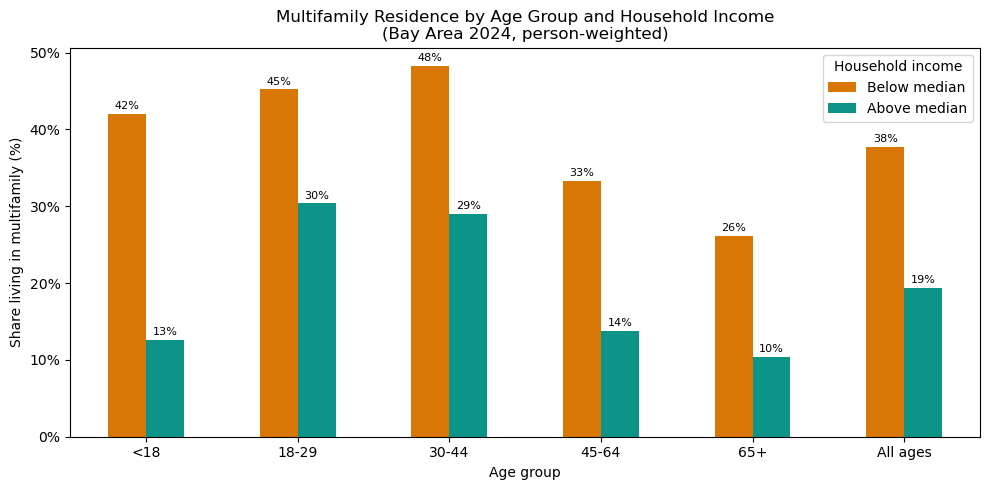

In [95]:
# Grouped bars: multifamily share by age group, split by income segment
ax = mf_pivot.plot(
    kind='bar', figsize=(10, 5),
    color={'Below median': '#d97706', 'Above median': '#0d9488'},
)

region = 'Bay Area' if COUNTY_SUBSET is not None else 'National'
ax.set_title(f'Multifamily Residence by Age Group and Household Income\n({region} {REFERENCE_YEAR}, person-weighted)')
ax.set_xlabel('Age group')
ax.set_ylabel('Share living in multifamily (%)')
ax.legend(title='Household income')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()


=== Multifamily share (%) by age group and San Francisco vs. rest of region (2024) ===


is_sanfrancisco,Rest of region,San Francisco
age_group,,
<18,22.0,46.3
18-29,32.9,70.0
30-44,30.9,67.7
45-64,18.0,49.6
65+,16.3,46.2
All ages,23.6,56.8


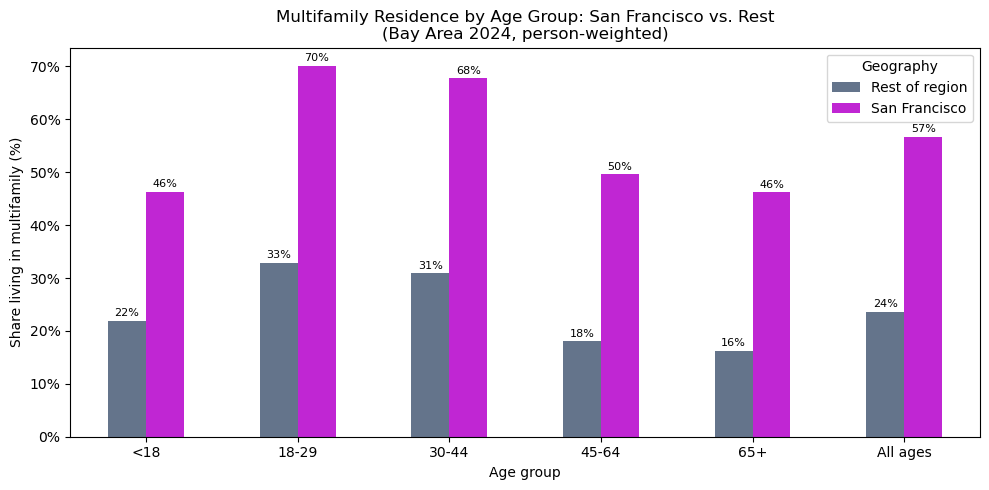

In [96]:
# Multifamily share by age group x San Francisco vs. rest of region (single-year snapshot)
mf_pivot_sf = mf_share_pivot('age_group', 'is_sanfrancisco', margins=True, margins_name='All ages')
mf_pivot_sf = mf_pivot_sf.drop(columns='All ages')  # keep age-total row, drop all-geographies column

print(f"=== Multifamily share (%) by age group and San Francisco vs. rest of region ({REFERENCE_YEAR}) ===")
display(mf_pivot_sf.round(1))

# Grouped bars: San Francisco vs. rest of region within each age group
ax = mf_pivot_sf.plot(
    kind='bar', figsize=(10, 5),
    color={'Rest of region': '#64748b', 'San Francisco': '#c026d3'},
)

region = 'Bay Area' if COUNTY_SUBSET is not None else 'National'
ax.set_title(f'Multifamily Residence by Age Group: San Francisco vs. Rest\n({region} {REFERENCE_YEAR}, person-weighted)')
ax.set_xlabel('Age group')
ax.set_ylabel('Share living in multifamily (%)')
ax.legend(title='Geography')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()


=== Multifamily share (%) by age group and survey year ===


year,2017,2024
age_group,,
<18,26.3,23.8
18-29,38.0,37.3
30-44,35.9,35.6
45-64,20.5,21.4
65+,20.1,19.6
All ages,27.9,27.2


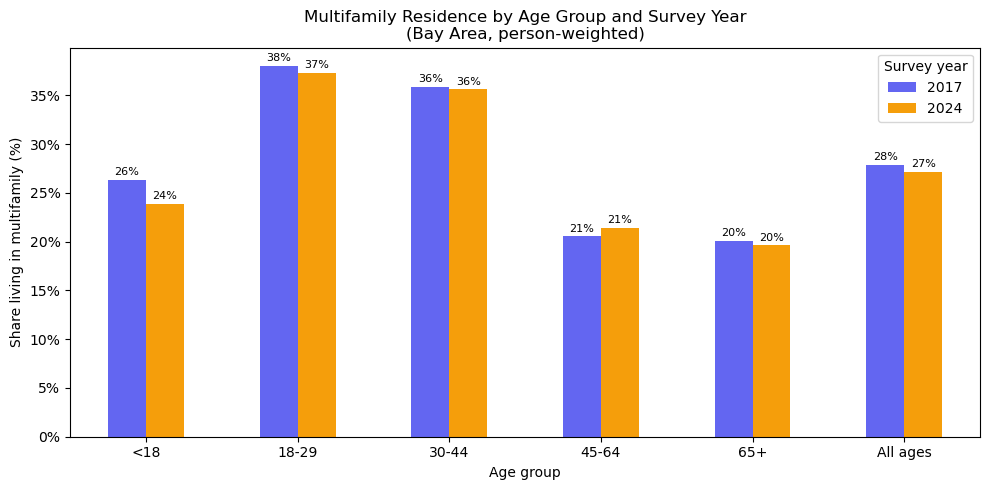

In [97]:
# Multifamily share by age group x survey year (person-weighted), with an "All ages" total
mf_pivot_year = mf_share_pivot('age_group', 'year', margins=True, margins_name='All ages')
mf_pivot_year = mf_pivot_year.drop(columns='All ages')  # keep age-total row, drop all-years column

print("=== Multifamily share (%) by age group and survey year ===")
display(mf_pivot_year.round(1))

# Grouped bars: one bar per year within each age group
year_colors = dict(zip(mf_pivot_year.columns, ['#6366f1', '#f59e0b', '#10b981', '#ef4444']))
ax = mf_pivot_year.plot(
    kind='bar', figsize=(10, 5),
    color=[year_colors[y] for y in mf_pivot_year.columns],
)

region = 'Bay Area' if COUNTY_SUBSET is not None else 'National'
ax.set_title(f'Multifamily Residence by Age Group and Survey Year\n({region}, person-weighted)')
ax.set_xlabel('Age group')
ax.set_ylabel('Share living in multifamily (%)')
ax.legend(title='Survey year')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()


=== Household share (%) by building size and survey year ===


year,2017,2024
bld_desc,,
Mobile home/trailer,1.8,1.9
One-family house detached,53.2,51.9
One-family house attached,9.3,9.5
2 Apartments,3.5,3.0
3-4 Apartments,6.5,6.3
5-9 Apartments,5.5,5.3
10-19 Apartments,5.3,5.1
20-49 Apartments,5.2,5.5
50 or more apartments,9.5,11.4


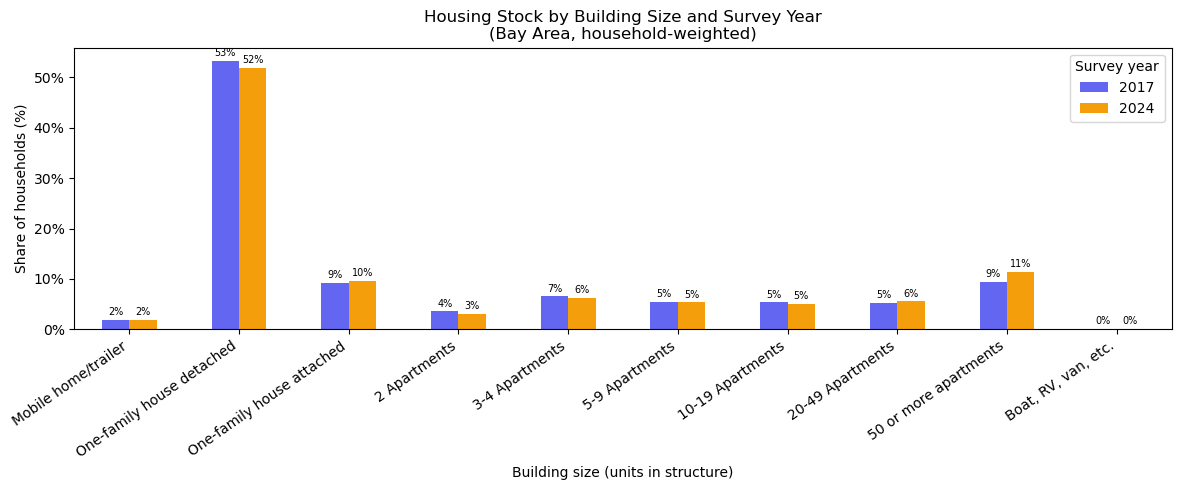

In [99]:
# Building-size (BLD) distribution by survey year — household-weighted (WGTP)
# Measured on h_df (one row per household) so this is the housing-stock mix, not persons.
bld_order = list(bld_mapping.values())   # natural order: SF detached/attached ... apartments ... other
h_bld = h_df.copy()
h_bld['bld_code'] = h_bld['BLD'].fillna(-1).map(lambda x: f'{x:02.0f}')
h_bld['bld_desc'] = pd.Categorical(h_bld['bld_code'].map(bld_mapping),
                                   categories=bld_order, ordered=True)

# Sum household weight by building type x year, then convert to within-year share.
hh_by_bld_year = h_bld.pivot_table(index='bld_desc', columns='year', values='WGTP',
                                   aggfunc='sum', observed=True)
bld_share = hh_by_bld_year.div(hh_by_bld_year.sum(axis=0), axis=1) * 100

print("=== Household share (%) by building size and survey year ===")
display(bld_share.round(1))

# Grouped bars: building size on X, one bar per year
ax = bld_share.plot(
    kind='bar', figsize=(12, 5),
    color=[year_colors[y] for y in bld_share.columns],
)

region = 'Bay Area' if COUNTY_SUBSET is not None else 'National'
ax.set_title(f'Housing Stock by Building Size and Survey Year\n({region}, household-weighted)')
ax.set_xlabel('Building size (units in structure)')
ax.set_ylabel('Share of households (%)')
ax.legend(title='Survey year')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.xticks(rotation=35, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=7)

plt.tight_layout()
plt.show()


=== Vacancy rate (%) by building size and survey year ===


year,2017,2024
bld_desc,,
Mobile home/trailer,8.3,8.4
One-family house detached,5.2,4.9
One-family house attached,4.7,5.0
2 Apartments,11.2,8.8
3-4 Apartments,6.7,9.2
5-9 Apartments,6.5,8.7
10-19 Apartments,9.1,9.8
20-49 Apartments,8.0,10.4
50 or more apartments,10.5,10.2


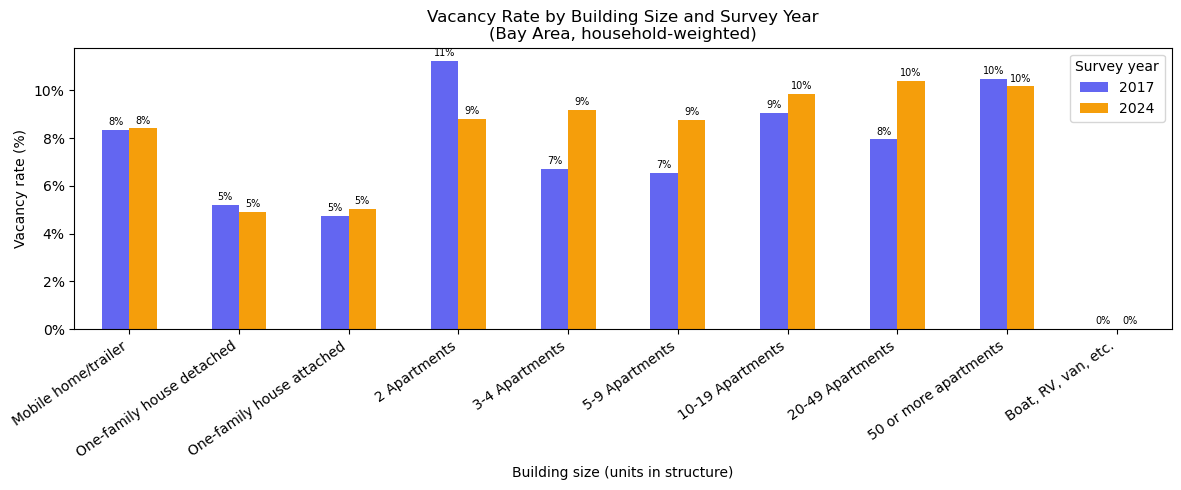

In [109]:
# Vacancy rate by building size and survey year — household-weighted (WGTP).
# Tests the hypothesis that the stock tilting toward large (50+) structures while the
# MF *residence* share slips is reconciled by HIGHER VACANCY in larger buildings.
# VACS is populated only for vacant units, so VACS.notna() flags a vacant unit; vacancy
# rate = vacant WGTP / all WGTP within each building-size x year cell.
h_vac = h_df.copy()
h_vac['bld_code'] = h_vac['BLD'].fillna(-1).map(lambda x: f'{x:02.0f}')
h_vac['bld_desc'] = pd.Categorical(h_vac['bld_code'].map(bld_mapping),
                                   categories=bld_order, ordered=True)
h_vac['is_vacant'] = h_vac['VACS'].notna()
h_vac['vacant_weight'] = h_vac['WGTP'].where(h_vac['is_vacant'], 0)

# Sum numerator (vacant units) and denominator (all units) separately so the rate is a
# ratio of weighted sums (margins stay correctly weighted).
vac_num = h_vac.pivot_table(index='bld_desc', columns='year', values='vacant_weight',
                            aggfunc='sum', observed=True, margins=True, margins_name='All sizes')
vac_den = h_vac.pivot_table(index='bld_desc', columns='year', values='WGTP',
                            aggfunc='sum', observed=True, margins=True, margins_name='All sizes')
vacancy_rate = (vac_num / vac_den * 100)
year_cols = [c for c in vacancy_rate.columns if c != 'All sizes']  # drop the row-margin column; keep the row-margin row
vacancy_rate = vacancy_rate[year_cols]

print("=== Vacancy rate (%) by building size and survey year ===")
display(vacancy_rate.round(1))

# Grouped bars: building size on X (drop the 'All sizes' margin row from the chart), bars by year
vac_plot = vacancy_rate.drop(index='All sizes')
ax = vac_plot.plot(
    kind='bar', figsize=(12, 5),
    color=[year_colors[y] for y in vac_plot.columns],
)

region = 'Bay Area' if COUNTY_SUBSET is not None else 'National'
ax.set_title(f'Vacancy Rate by Building Size and Survey Year\n({region}, household-weighted)')
ax.set_xlabel('Building size (units in structure)')
ax.set_ylabel('Vacancy rate (%)')
ax.legend(title='Survey year')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.xticks(rotation=35, ha='right')

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=7)

plt.tight_layout()
plt.show()

## Reconciling the stock, residence, and vacancy charts (Bay Area, 2017 to 2024)

**The puzzle.** Three household/person-weighted views of the same two ACS PUMS vintages point in directions that look contradictory at first glance:

1. **Building-stock mix** (household-weighted, `bld_share`) tilts toward larger structures: one-family detached slips **53.2% → 51.9%**, while **50+ unit** buildings climb **9.5% → 11.4%** (with 20-49 also up). The region added very little single-family and mostly large multifamily over the period.
2. **Multifamily *residence* share** (person-weighted MF share by age, `mf_pivot_year`) goes the *other* way — essentially flat-to-down, **27.9% → 27.2%** region-wide (SF roughly flat at **54.7% → 56.8%**). More apartments in the stock, but not a higher share of *people* living in them.
3. **Vacancy by building size** (`vacancy_rate`) supplies the missing link: vacancy is structurally **~2× higher in multifamily (~9–11%) than in single-family (~5%)**, and it *rose* across most mid-sized MF tiers 2017 → 2024.

**The reconciliation.** These are consistent, not contradictory. Every unit the region adds in a large building carries roughly double the odds of sitting empty (~10%) versus a single-family home (~5%). So a stock mix shifting toward apartments mechanically "leaks" occupancy — the new units inflate the unit *count* faster than the resident *count*. Layered on top, vacancy *rates* softened within the 3-to-49-unit band, which drags the person-weighted MF residence share down even as the building stock unmistakably tilts multifamily. The overall vacancy rate ticked up **6.4% → 6.7%**, with essentially all of the increase concentrated in multifamily.

**Where the vacancy change actually lives (the nuance).** It is **not** a big-building story:

- **50+ units: 10.5% → 10.2%** — flat-to-*down*, the lone large-MF exception. Already near double-digit vacancy in 2017; it didn't get emptier, there are just *more* of them. Its contribution to the regional total is via growth-in-count at a stable rate, not a worsening rate.
- **3-4 (6.7 → 9.2), 5-9 (6.5 → 8.7), 10-19 (9.1 → 9.8), 20-49 (8.0 → 10.4)** — a broad level-shift up across mid-sized MF. **20-49** posts the largest jump (+2.4 pts) but sits in a thin slice of the stock (~5–5.5%), so its leverage on the regional rate is limited.
- **2-unit: 11.2% → 8.8%** — the one MF category that *tightened*.
- **Single-family detached: 5.2% → 4.9%** — flat-to-down; the SF segment did not loosen.

**Working hypothesis.** The post-2017 housing additions are disproportionately large multifamily, a segment that runs persistently high vacancy (~10%) and, in the 3–49-unit tiers, got *softer* over the period. Because these units are absorbed more slowly (and/or by smaller, often older or single-person households), the region can build decisively toward apartments while the share of *people* housed in multifamily stays flat or edges down. In short: **the stock moved toward multifamily; occupancy did not follow, and elevated + rising mid-MF vacancy is the mechanism that absorbs the gap.** A future check could decompose the 0.3-pt regional vacancy rise into a composition component (tilt toward high-vacancy large buildings) versus a within-tier rate component to size each channel precisely.

=== Multifamily share (%) by age group and survey year — San Francisco only ===


year,2017,2024
age_group,,
<18,46.6,46.3
18-29,61.6,70.0
30-44,65.9,67.7
45-64,47.2,49.6
65+,45.2,46.2
All ages,54.7,56.8


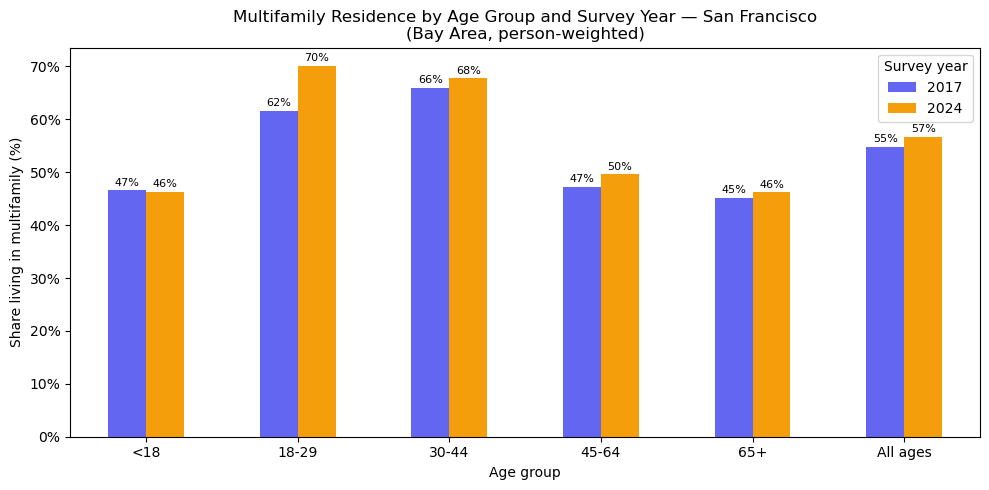

In [100]:
# Within San Francisco only: multifamily share by age group x survey year (change since 2017)
sf_only = merged_df[merged_df['is_sanfrancisco'] == 'San Francisco']
mf_pivot_sf_year = mf_share_pivot('age_group', 'year', margins=True, margins_name='All ages', data=sf_only)
mf_pivot_sf_year = mf_pivot_sf_year.drop(columns='All ages')  # keep age-total row, drop all-years column

print("=== Multifamily share (%) by age group and survey year — San Francisco only ===")
display(mf_pivot_sf_year.round(1))

# Grouped bars: one bar per year within each age group
year_colors = dict(zip(mf_pivot_sf_year.columns, ['#6366f1', '#f59e0b', '#10b981', '#ef4444']))
ax = mf_pivot_sf_year.plot(
    kind='bar', figsize=(10, 5),
    color=[year_colors[y] for y in mf_pivot_sf_year.columns],
)

region = 'Bay Area' if COUNTY_SUBSET is not None else 'National'
ax.set_title(f'Multifamily Residence by Age Group and Survey Year — San Francisco\n({region}, person-weighted)')
ax.set_xlabel('Age group')
ax.set_ylabel('Share living in multifamily (%)')
ax.legend(title='Survey year')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
plt.xticks(rotation=0)

for container in ax.containers:
    ax.bar_label(container, fmt='%.0f%%', padding=2, fontsize=8)

plt.tight_layout()
plt.show()


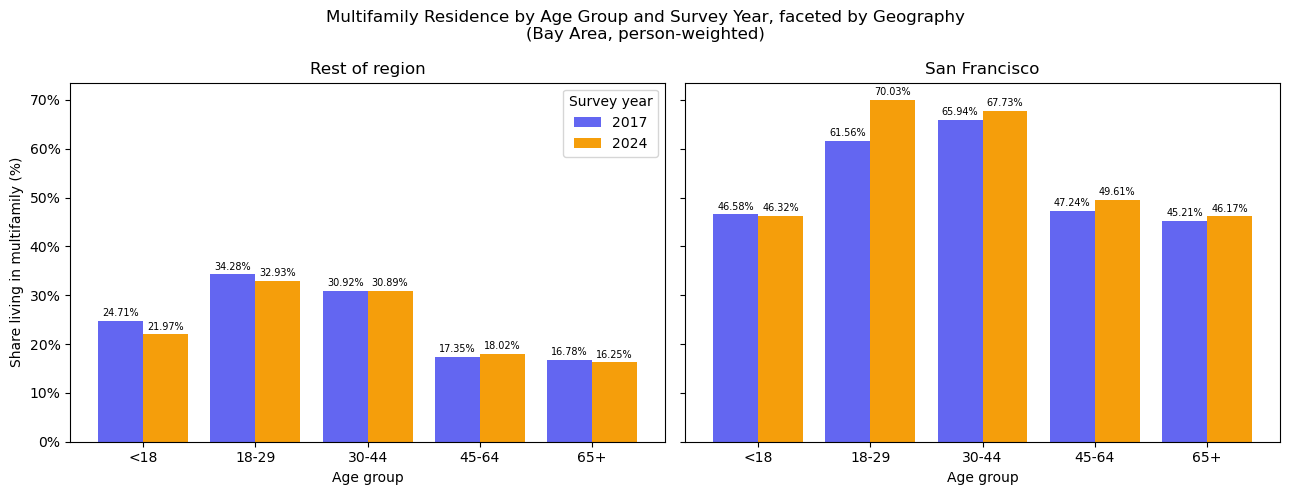

In [111]:
# Faceted variant: X=age, bars=survey year, one panel per geography (SF vs. rest of region)
geographies = list(merged_df['is_sanfrancisco'].cat.categories)
year_colors = dict(zip(sorted(merged_df['year'].unique()),
                       ['#6366f1', '#f59e0b', '#10b981', '#ef4444']))

fig, axes = plt.subplots(1, len(geographies), figsize=(13, 5), sharey=True)
for ax, geo in zip(axes, geographies):
    piv = mf_share_pivot('age_group', 'year', data=merged_df[merged_df['is_sanfrancisco'] == geo])
    piv.plot(kind='bar', ax=ax, color=[year_colors[y] for y in piv.columns],
             legend=(ax is axes[0]), width=0.8)
    ax.set_title(geo)
    ax.set_xlabel('Age group')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(decimals=0))
    ax.tick_params(axis='x', rotation=0)
    for container in ax.containers:
        ax.bar_label(container, fmt='%.2f%%', padding=2, fontsize=7)

axes[0].set_ylabel('Share living in multifamily (%)')
if axes[0].get_legend():
    axes[0].legend(title='Survey year')

region = 'Bay Area' if COUNTY_SUBSET is not None else 'National'
fig.suptitle(f'Multifamily Residence by Age Group and Survey Year, faceted by Geography\n({region}, person-weighted)')
plt.tight_layout()
plt.show()


In [102]:
mf_pivot

income_group,Below median,Above median
age_group,,
<18,42.017499,12.633363
18-29,45.209696,30.387808
30-44,48.227682,28.978602
45-64,33.292899,13.762620
65+,26.134728,10.390608
All ages,37.750627,19.379613


In [103]:
mf_by_age_income

Persons  Multifamily Residents  Multifamily Share %
age_group income_group                                                       
<18       Below median   552020.0               231945.0            42.017499
          Above median   895486.0               113130.0            12.633363
18-29     Below median   532127.0               240573.0            45.209696
          Above median   614118.0               186617.0            30.387808
30-44     Below median   603193.0               290906.0            48.227682
          Above median  1147809.0               332619.0            28.978602
45-64     Below median   755137.0               251407.0            33.292899
          Above median  1183699.0               162908.0            13.762620
65+       Below median   798738.0               208748.0            26.134728
          Above median   566040.0                58815.0            10.390608

In [42]:
# Sanity check: harmonized year-built decade by source vintage
pd.crosstab(h_df['yrblt_decade'], h_df['year'], dropna=False)


year,2017,2024
yrblt_decade,,
NaN,1126,3366
Pre-1940,1108,4598
1940s,810,1906
1950s,1702,4079
1960s,1752,4180
1970s,2149,5084
1980s,1519,3772
1990s,1093,2509
2000s,1031,2649
